# WebP Compression Lab
Exploring the effect of WebP quality settings on file size and image fidelity.

In [2]:
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2  

## 1. Save image at various WebP quality levels and plot them

Quality 10: 38928 bytes
Quality 20: 39708 bytes
Quality 30: 40680 bytes
Quality 40: 41900 bytes
Quality 50: 43026 bytes
Quality 60: 44006 bytes
Quality 70: 45064 bytes
Quality 80: 48146 bytes
Quality 90: 56440 bytes
Quality 100: 85944 bytes


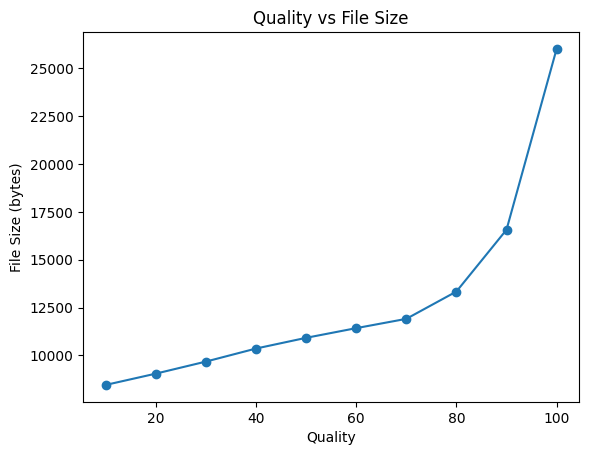

Saved output/quality_vs_size.png


In [3]:
img = Image.open("img/dice.png")

qualities = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

for q in qualities:
    filename = f"output/dice_q{q}.webp"
    img.save(filename, "WEBP", quality=q)
    size = os.path.getsize(filename)
    print(f"Quality {q}: {size} bytes")


sizes = [os.path.getsize(f"output/pingu_q{q}.webp") for q in qualities]

plt.figure()
plt.plot(qualities, sizes, marker='o')
plt.xlabel("Quality")
plt.ylabel("File Size (bytes)")
plt.title("Quality vs File Size")
plt.savefig("output/quality_vs_size.png")
plt.show()
print("Saved output/quality_vs_size.png")

## 3. Visual Comparison: Original vs Compressed (q=10) vs Difference

In [ ]:
original = np.array(Image.open("img/dice.png"))
compressed = np.array(Image.open("output/dice_q10.webp"))


diff = cv2.absdiff(original, compressed)

cv2.imshow("diff", diff)
cv2.imshow("original", original)
cv2.imshow("compressed", compressed)
cv2.waitKey(0)
cv2.destroyAllWindows()


# Compare different compression algorithms

In [15]:

noise = np.random.randint(0, 255, (1000 ,1000,3), dtype=np.uint8)
Image.fromarray(noise).save("output/noise.png")
Image.fromarray(noise).save("output/noise.webp")
Image.fromarray(noise).save("output/noise.jpg")
Image.fromarray(noise).save("output/noise.avif")


# Now compare the file sizes
import os

for ext in ["png", "webp", "jpg", "avif"]:
    path = f"output/noise.{ext}"
    size = os.path.getsize(path)
    print(f"{ext.upper()} size: {size / 1024:.2f} KB")


PNG size: 2934.76 KB
WEBP size: 664.21 KB
JPG size: 587.96 KB
AVIF size: 768.59 KB


## 4. Image Quality Metrics: PSNR & SSIM

In [18]:
import cv2
from skimage.metrics import structural_similarity as ssim

def compute_psnr(img1, img2):
    mse = np.mean((img1.astype(float) - img2.astype(float)) ** 2)
    if mse == 0:
        return float("inf")
    PIXEL_MAX = 255.0
    return 10 * np.log10((PIXEL_MAX ** 2) / mse)

def compute_ssim(img1, img2):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    score, _ = ssim(gray1, gray2, full=True)
    return score

# Load images using cv2 (convert BGR -> RGB to match PIL convention)
orig_cv = cv2.cvtColor(cv2.imread("img/pingu.png"), cv2.COLOR_BGR2RGB)

results = []
for q in qualities:
    comp_cv = cv2.cvtColor(cv2.imread(f"output/pingu_q{q}.webp"), cv2.COLOR_BGR2RGB)
    psnr = compute_psnr(orig_cv, comp_cv)
    s = compute_ssim(orig_cv, comp_cv)
    results.append((q, psnr, s))
    print(f"Quality {q:3d} | PSNR: {psnr:.2f} dB | SSIM: {s:.4f}")

Quality  10 | PSNR: 25.25 dB | SSIM: 0.9299
Quality  30 | PSNR: 25.61 dB | SSIM: 0.9498
Quality  50 | PSNR: 25.78 dB | SSIM: 0.9564
Quality  70 | PSNR: 25.84 dB | SSIM: 0.9604
Quality  90 | PSNR: 25.96 dB | SSIM: 0.9669


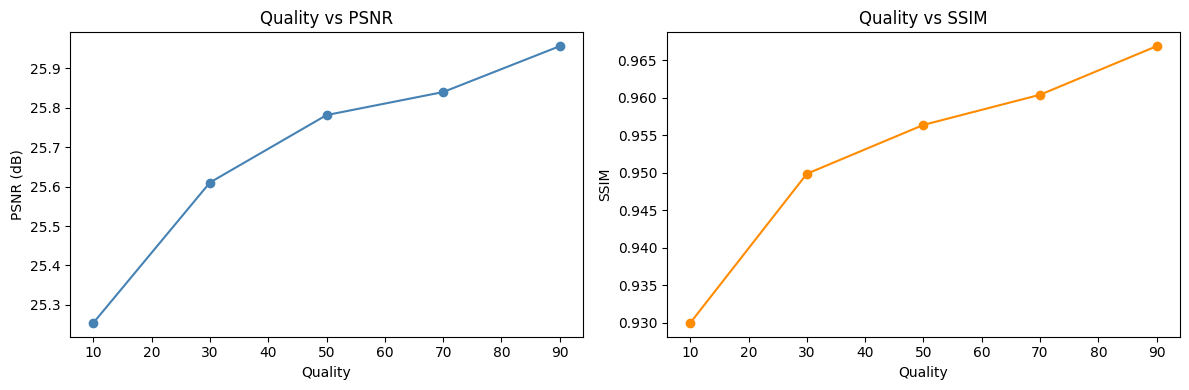

In [19]:
qs, psnrs, ssims = zip(*results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(qs, psnrs, marker="o", color="steelblue")
ax1.set_xlabel("Quality")
ax1.set_ylabel("PSNR (dB)")
ax1.set_title("Quality vs PSNR")

ax2.plot(qs, ssims, marker="o", color="darkorange")
ax2.set_xlabel("Quality")
ax2.set_ylabel("SSIM")
ax2.set_title("Quality vs SSIM")

plt.tight_layout()
plt.savefig("output/quality_metrics.png")
plt.show()